# Fashion Preferences  Predicting Age Group & Gender
## Data Bootcamp Final Project

### Executive Summary
This project uses a fashion preferences survey dataset to build classification models that predict a respondent's **age group** and **gender** from their style habits, shopping behaviour, and lifestyle choices. We compare a Logistic Regression baseline, a KNN classifier, and a tuned Decision Tree classifier. The **Logistic Regression achieves the best Age Group accuracy (~87%)**, while all models perform similarly and poorly for Gender (~53–63%) on the held-out test set.

**Dataset:** [Kaggle Fashion Dataset (Rahul2312)](https://www.kaggle.com/datasets/rahul2312kaggle/fashion-dataset)  **Targets:** Age Group & Gender  **Models:** Logistic Regression  KNN  Decision Tree (Grid Search tuned)


## Data Loading & Setup

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
# Download latest version
path = kagglehub.dataset_download("rahul2312kaggle/fashion-dataset")
print("Path to dataset files:", path)

df = pd.read_csv(Path(path) / "Fashion(Data Points) - Form responses 1.csv")

df.columns

Using Colab cache for faster access to the 'fashion-dataset' dataset.
Path to dataset files: /kaggle/input/fashion-dataset


Index(['Timestamp', '  1.Age Group  ', '  2.Gender  ', '  3.Profession  ',
       'Section 2: Style Preferences\n4. How would you describe your go-to daily outfit? (Select one)  ',
       ' 5. What’s your favorite color palette for clothing?  ',
       ' 6. Do you prioritize functionality or aesthetics in your outfits?  ',
       '  7.Which of these best describes your wardrobe?  ',
       'Section 3: Shopping Habits\n8. How often do you shop for new clothes?  ',
       '  9.What influences your clothing purchases the most?  ',
       ' 10. Where do you typically shop for clothes? (Select all that apply)  ',
       'Section 4: Lifestyle\n11. How often do you attend formal events?  ',
       '  12.Do you often experiment with new styles or stick to what you know?  ',
       ' 13. What kind of footwear do you wear most often?  ',
       '14. How active is your daily lifestyle?  ',
       'Section 5: Personal Preferences\n15. How important is comfort in your clothing choices\n',
       ' 


## Data Description

The dataset is a Google Form survey with ~150 respondents and 20 columns covering demographics, style preferences, shopping habits, lifestyle, and personal values.

We predict two demographic targets:
- **Age Group**  categorical (18-24, 25-34, 35-44, 45+)
- **Gender**  binary (Male / Female)

All remaining columns serve as predictive features.

In [2]:
# Renaming columns
df = df.rename(columns={
    '  3.Profession  ': 'Profession',
    'Section 2: Style Preferences\n4. How would you describe your go-to daily outfit? (Select one)  ': 'Daily_outfit',
    ' 5. What\u2019s your favorite color palette for clothing?  ': 'Color_palette',
    ' 6. Do you prioritize functionality or aesthetics in your outfits?  ': 'Functionality_vs_aesthetics',
    '  7.Which of these best describes your wardrobe?  ': 'Wardrobe_type',
    'Section 3: Shopping Habits\n8. How often do you shop for new clothes?  ': 'Shopping_Frequency',
    '  9.What influences your clothing purchases the most?  ' : 'Influence',
    ' 10. Where do you typically shop for clothes? (Select all that apply)  ' : 'Stores',
    'Section 4: Lifestyle\n11. How often do you attend formal events?  ': 'Formal_event_attendance_frequency',
    '  12.Do you often experiment with new styles or stick to what you know?  ': 'Style_experimentation_frequency',
    ' 13. What kind of footwear do you wear most often?  ': 'Footwear',
    '14. How active is your daily lifestyle?  ': 'Activity Level',
    'Section 5: Personal Preferences\n15. How important is comfort in your clothing choices\n': 'Importance of Clothing',
    ' 16.If you had to choose, would you prefer timeless pieces or trendy items?  ': 'Trendy vs Timeless',
    '17. From scale 1-10 how much do you think your clothing style reflects about your personality?': 'Clothing on Personality'})

# Dropping the last two columns with mostly nan values
df.drop(columns = {'Timestamp', 'Section 2: Style Preferences', 'Column 18'}, inplace=True)

# Changing Clothing on Personality to int
df['Clothing on Personality'].fillna(df['Clothing on Personality'].mean()).astype(int)
df.head()

,1.Age Group,2.Gender,Profession,Daily_outfit,Color_palette,Functionality_vs_aesthetics,Wardrobe_type,Shopping_Frequency,Influence,Stores,Formal_event_attendance_frequency,Style_experimentation_frequency,Footwear,Activity Level,Importance of Clothing,Trendy vs Timeless,Clothing on Personality
0,18–24,Female,Student,"Chic (e.g., tailored, stylish)","Pastels (soft pink, baby blue)",Slightly prefer aesthetics,Mix-and-match (varied styles),Rarely,Comfort,Local boutiques,- Occasionally (a few times a year),Sometimes experiment,Sneakers,Mostly sedentary,- Extremely important,"Mostly trendy, some timeless",8.0
1,18–24,Female,Student,"Casual (e.g., jeans, t-shirts)","Dark tones (navy, maroon)",Slightly prefer functionality,Mix-and-match (varied styles),Every few months,Sustainability,Thrift stores,- Occasionally (a few times a year),Sometimes experiment,Sandals/Flats,Moderately active,- Somewhat important,"Mostly timeless, some trendy",6.0
2,18–24,Female,Student,"Casual (e.g., jeans, t-shirts)","Neutral (black, white, beige)",Slightly prefer functionality,Minimalist (few versatile pieces),Monthly,Comfort,Local boutiques,- Occasionally (a few times a year),Rarely experiment,Sneakers,Moderately active,- Extremely important,"Mostly timeless, some trendy",9.0
3,18–24,Male,Student,"Casual (e.g., jeans, t-shirts)","Neutral (black, white, beige)",Equal balance of both,Specialized (specific to one style),Every few months,Comfort,Thrift stores,- Rarely (less than once a year),Sometimes experiment,Sneakers,"Very active (e.g., gym, outdoor activities)",- Somewhat important,Always timeless,6.0
4,18–24,Male,Student,"Casual (e.g., jeans, t-shirts)","Neutral (black, white, beige)",Slightly prefer aesthetics,Minimalist (few versatile pieces),Rarely,Comfort,Thrift stores,- Occasionally (a few times a year),Rarely experiment,Sneakers,"Very active (e.g., gym, outdoor activities)",- Somewhat important,"Mostly timeless, some trendy",6.0


In [3]:
print("Columns:", df.columns.tolist())
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head()

Columns: ['  1.Age Group  ', '  2.Gender  ', 'Profession', 'Daily_outfit', 'Color_palette', 'Functionality_vs_aesthetics', 'Wardrobe_type', 'Shopping_Frequency', 'Influence', 'Stores', 'Formal_event_attendance_frequency', 'Style_experimentation_frequency', 'Footwear', 'Activity Level', 'Importance of Clothing', 'Trendy vs Timeless', 'Clothing on Personality']

Missing values per column:
Daily_outfit                         1
Functionality_vs_aesthetics          1
Wardrobe_type                        2
Shopping_Frequency                   1
Influence                            2
Stores                               2
Formal_event_attendance_frequency    2
Style_experimentation_frequency      2
Footwear                             2
Activity Level                       2
Importance of Clothing               2
Trendy vs Timeless                   4
Clothing on Personality              3
dtype: int64


,1.Age Group,2.Gender,Profession,Daily_outfit,Color_palette,Functionality_vs_aesthetics,Wardrobe_type,Shopping_Frequency,Influence,Stores,Formal_event_attendance_frequency,Style_experimentation_frequency,Footwear,Activity Level,Importance of Clothing,Trendy vs Timeless,Clothing on Personality
0,18–24,Female,Student,"Chic (e.g., tailored, stylish)","Pastels (soft pink, baby blue)",Slightly prefer aesthetics,Mix-and-match (varied styles),Rarely,Comfort,Local boutiques,- Occasionally (a few times a year),Sometimes experiment,Sneakers,Mostly sedentary,- Extremely important,"Mostly trendy, some timeless",8.0
1,18–24,Female,Student,"Casual (e.g., jeans, t-shirts)","Dark tones (navy, maroon)",Slightly prefer functionality,Mix-and-match (varied styles),Every few months,Sustainability,Thrift stores,- Occasionally (a few times a year),Sometimes experiment,Sandals/Flats,Moderately active,- Somewhat important,"Mostly timeless, some trendy",6.0
2,18–24,Female,Student,"Casual (e.g., jeans, t-shirts)","Neutral (black, white, beige)",Slightly prefer functionality,Minimalist (few versatile pieces),Monthly,Comfort,Local boutiques,- Occasionally (a few times a year),Rarely experiment,Sneakers,Moderately active,- Extremely important,"Mostly timeless, some trendy",9.0
3,18–24,Male,Student,"Casual (e.g., jeans, t-shirts)","Neutral (black, white, beige)",Equal balance of both,Specialized (specific to one style),Every few months,Comfort,Thrift stores,- Rarely (less than once a year),Sometimes experiment,Sneakers,"Very active (e.g., gym, outdoor activities)",- Somewhat important,Always timeless,6.0
4,18–24,Male,Student,"Casual (e.g., jeans, t-shirts)","Neutral (black, white, beige)",Slightly prefer aesthetics,Minimalist (few versatile pieces),Rarely,Comfort,Thrift stores,- Occasionally (a few times a year),Rarely experiment,Sneakers,"Very active (e.g., gym, outdoor activities)",- Somewhat important,"Mostly timeless, some trendy",6.0



## EDA

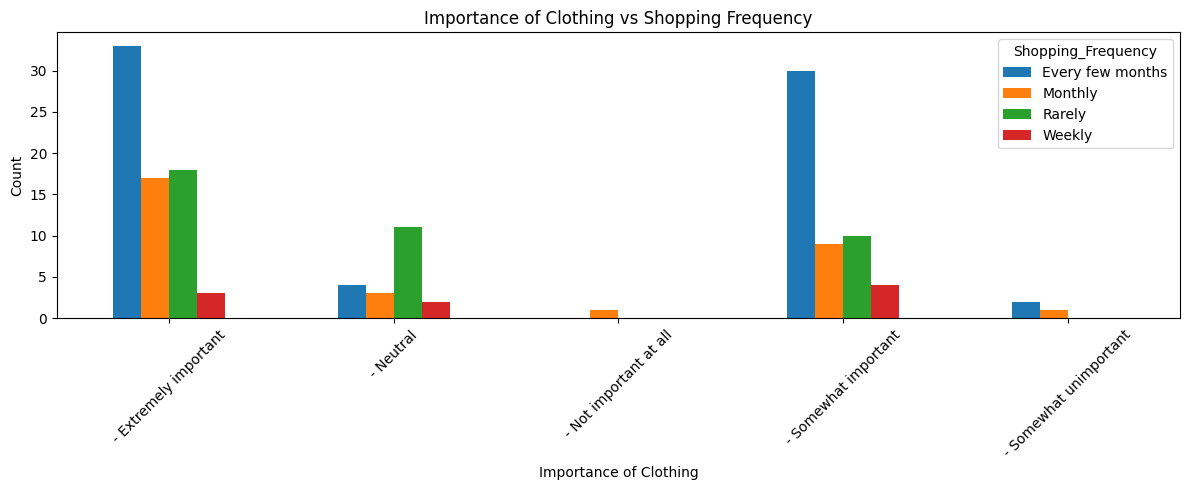

In [4]:
# Importance of clothing score on shopping frequency
df.groupby(['Importance of Clothing', 'Shopping_Frequency']).size().unstack().plot(kind='bar', figsize=(12, 5))
plt.title('Importance of Clothing vs Shopping Frequency')
plt.xlabel('Importance of Clothing')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()


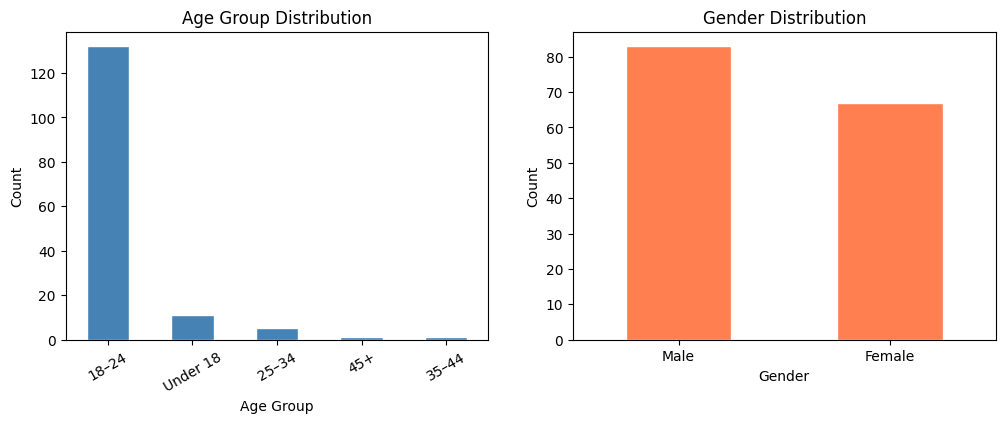

In [5]:
#  Target distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['  1.Age Group  '].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Age Group Distribution')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

df['  2.Gender  '].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Gender Distribution')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

Text(0.5, 0, 'Mean Score (1-10)')

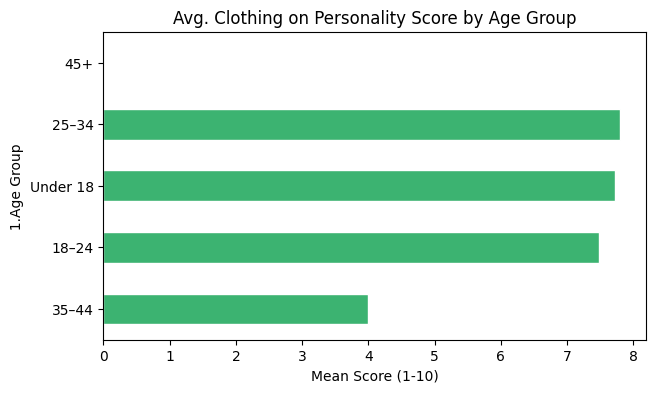

In [6]:
#  Style-Personality score by age group
df.groupby('  1.Age Group  ')['Clothing on Personality'].mean().sort_values().plot(
    kind='barh', figsize=(7, 4), color='mediumseagreen', edgecolor='white')
plt.title('Avg. Clothing on Personality Score by Age Group')
plt.xlabel('Mean Score (1-10)')

Text(0.5, 0, 'Count')

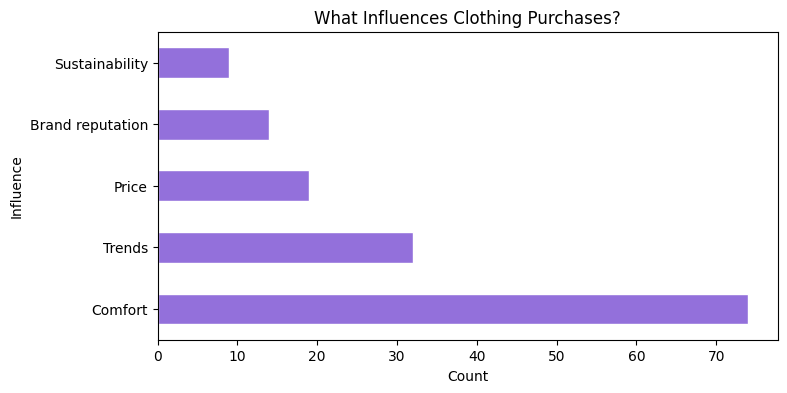

In [7]:
#  Top shopping influences
df['Influence'].value_counts().head(8).plot(
    kind='barh', figsize=(8, 4), color='mediumpurple', edgecolor='white')
plt.title('What Influences Clothing Purchases?')
plt.xlabel('Count')


## Our Models & Methods

We build a preprocessing + modelling pipeline and wrap each classifier in `MultiOutputClassifier` to predict both targets simultaneously.

| Step | Tool |
|---|---|
| Missing categoricals | `SimpleImputer(strategy='constant', fill_value='unknown')` |
| Ordered categories | `OrdinalEncoder` |
| Nominal categories | `OneHotEncoder(drop='first')` |
| Numeric score | `StandardScaler` |

**Train / test split:** 75% / 25% (`random_state=12`)

**Models compared:**
- Logistic Regression  regularised linear baseline
- Decision Tree  tuned with Grid Search (depth, split criterion, leaf size)
- KNN  tuned with Grid Search (number of neighbors)

In [8]:
import sklearn
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import precision_score, recall_score
from sklearn.multioutput import MultiOutputClassifier

print(df.dtypes)

  1.Age Group                         object
  2.Gender                            object
Profession                            object
Daily_outfit                          object
Color_palette                         object
Functionality_vs_aesthetics           object
Wardrobe_type                         object
Shopping_Frequency                    object
Influence                             object
Stores                                object
Formal_event_attendance_frequency     object
Style_experimentation_frequency       object
Footwear                              object
Activity Level                        object
Importance of Clothing                object
Trendy vs Timeless                    object
Clothing on Personality              float64
dtype: object


In [9]:
df['  1.Age Group  '].unique()

array(['18–24', '25–34', 'Under 18', '45+', '35–44'], dtype=object)

In [10]:
# Splitting the data into training and validation

df['Clothing on Personality'] = df['Clothing on Personality'].fillna(df['Clothing on Personality'].mean())

X = df.drop(columns=['  1.Age Group  ', '  2.Gender  '])
y = df[['  1.Age Group  ','  2.Gender  ']].copy()

y = df[['  1.Age Group  ', '  2.Gender  ']].copy()

y['  2.Gender  '] = y['  2.Gender  '].fillna(y['  2.Gender  '].mode()[0])
y['  2.Gender  '] = y['  2.Gender  '].map({'Female': 0, 'Male': 1})

y['  1.Age Group  '] = y['  1.Age Group  '].fillna(y['  1.Age Group  '].mode()[0])
y['  1.Age Group  '] = y['  1.Age Group  '].map({'Under 18': 0, '18–24': 1, '25–34': 2, '35–44': 3, '45+': 4})


# Grouping categorical columns for future imputations
cat_cols = X.select_dtypes('object').columns.tolist()
num_cols = X.select_dtypes('number').columns.tolist()

print(cat_cols)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=12)

# Imputer transformer
imputer = make_column_transformer(
    (SimpleImputer(strategy='constant', fill_value='unknown'), cat_cols),
    verbose_feature_names_out=False,
    remainder='passthrough'
)

# One Hot and Ordinal Encoding
ohe = make_column_transformer(
    (StandardScaler(), ['Clothing on Personality']),
    (OrdinalEncoder(categories=[['Rarely', 'Every few months', 'Monthly', 'Weekly']], handle_unknown='use_encoded_value', unknown_value=-1), ['Shopping_Frequency']),
    (OrdinalEncoder(categories=[['- Occasionally (a few times a year)', '- Rarely (less than once a year)', '- Frequently (weekly or monthly)', 'nan']], handle_unknown='use_encoded_value', unknown_value=-1), ['Formal_event_attendance_frequency']),
    (OrdinalEncoder(categories=[['Sometimes experiment', 'Rarely experiment', 'Always experiment']], handle_unknown='use_encoded_value', unknown_value=-1), ['Style_experimentation_frequency']),
    (OrdinalEncoder(categories=[['Always trendy', 'Mostly trendy, some timeless', 'Equal mix of both', 'Mostly timeless, some trendy', 'Always timeless']], handle_unknown='use_encoded_value', unknown_value=-1), ['Trendy vs Timeless']),
    (OrdinalEncoder(categories=[['Mostly sedentary', 'Moderately active', 'Very active (e.g., gym, outdoor activities)']], handle_unknown='use_encoded_value', unknown_value=-1), ['Activity Level']),
    (OrdinalEncoder(categories=[['- Extremely important', '- Somewhat important', '- Neutral', '- Somewhat unimportant','- Not important at all']], handle_unknown='use_encoded_value', unknown_value=-1), ['Importance of Clothing']),
    (OrdinalEncoder(categories=[[ 'Slightly prefer functionality', 'Equal balance of both', 'Slightly prefer aesthetics',]], handle_unknown='use_encoded_value', unknown_value=-1), ['Functionality_vs_aesthetics']),

    (OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), [
        'Profession',
        'Influence',
        'Stores',
        'Daily_outfit',
        'Color_palette',
        'Wardrobe_type',
        'Footwear',
    ]),
    remainder='passthrough',
    verbose_feature_names_out=False
)

sklearn.set_config(transform_output="pandas")

['Profession', 'Daily_outfit', 'Color_palette', 'Functionality_vs_aesthetics', 'Wardrobe_type', 'Shopping_Frequency', 'Influence', 'Stores', 'Formal_event_attendance_frequency', 'Style_experimentation_frequency', 'Footwear', 'Activity Level', 'Importance of Clothing', 'Trendy vs Timeless']



## Results & Interpretation

### Model 1  Logistic Regression (baseline)

In [11]:
# Logistic Regression

lgr = MultiOutputClassifier(LogisticRegression())

lgr_pipe = make_pipeline(imputer, ohe, lgr)

lgr_pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('simpleimputer',
                                                  SimpleImputer(fill_value='unknown',
                                                                strategy='constant'),
                                                  ['Profession', 'Daily_outfit',
                                                   'Color_palette',
                                                   'Functionality_vs_aesthetics',
                                                   'Wardrobe_type',
                                                   'Shopping_Frequency',
                                                   'Influence', 'Stores',
                                                   'Formal_event_attendance_frequency',
                                                   'Style_experi...
                                                                 unknown_value=-1),
                                                  ['Functionality_vs_aesthetics']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Profession', 'Influence',
                                                   'Stores', 'Daily_outfit',
                                                   'Color_palette',
                                                   'Wardrobe_type',
                                                   'Footwear'])],
                                   verbose_feature_names_out=False)),
                ('multioutputclassifier',
                 MultiOutputClassifier(estimator=LogisticRegression()))])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Text(0.5, 1.0, 'Logistic Regression - Gender')

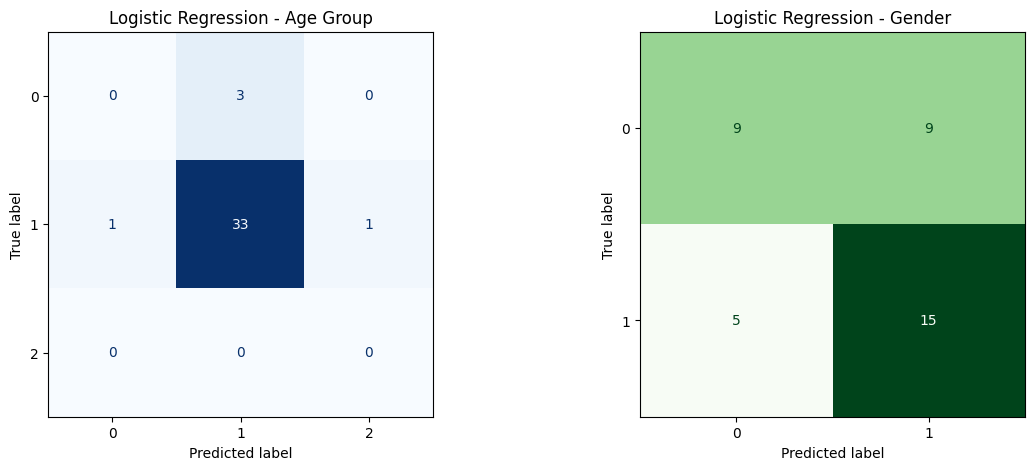

In [12]:
# Confusion Matrix  for logistic regression
yhat_lgr = lgr_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, 0], yhat_lgr[:, 0], ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression - Age Group')
ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, 1], yhat_lgr[:, 1], ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Logistic Regression - Gender')

In [13]:
# Important Metrics - Logistic Regression
print("Age Group")
print(classification_report(y_test.iloc[:, 0], yhat_lgr[:, 0]))

print("Gender")
print(classification_report(y_test.iloc[:, 1], yhat_lgr[:, 1]))

print("Age Group Accuracy:", accuracy_score(y_test.iloc[:, 0], yhat_lgr[:, 0]))
print("Gender Accuracy:", accuracy_score(y_test.iloc[:, 1], yhat_lgr[:, 1]))

Age Group
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.92      0.94      0.93        35
           2       0.00      0.00      0.00         0

    accuracy                           0.87        38
   macro avg       0.31      0.31      0.31        38
weighted avg       0.84      0.87      0.86        38

Gender
              precision    recall  f1-score   support

           0       0.64      0.50      0.56        18
           1       0.62      0.75      0.68        20

    accuracy                           0.63        38
   macro avg       0.63      0.62      0.62        38
weighted avg       0.63      0.63      0.63        38

Age Group Accuracy: 0.868421052631579
Gender Accuracy: 0.631578947368421


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u

Best params: {'multioutputclassifier__estimator__C': 100, 'multioutputclassifier__estimator__penalty': 'l2', 'multioutputclassifier__estimator__solver': 'liblinear'}
Best CV score: 0.5264822134387351

Tuned Age Group Accuracy: 0.7894736842105263
Tuned Gender Accuracy: 0.6842105263157895


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Text(0.5, 1.0, 'Tuned Logistic Regression (Gender)')

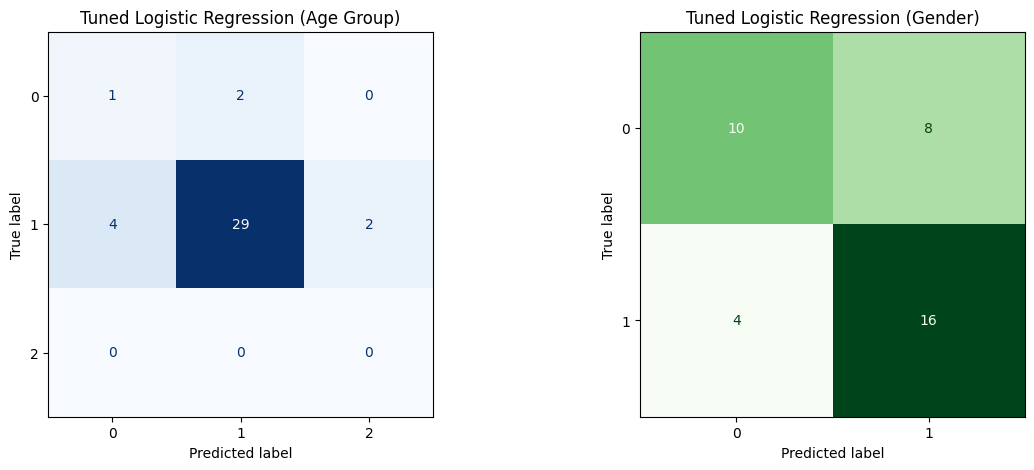

In [14]:
# Grid Search - logistic regression

lgr_param_grid = {
    'multioutputclassifier__estimator__C': [0.01, 0.1, 1, 10, 100],
    'multioutputclassifier__estimator__penalty': ['l1', 'l2'],
    'multioutputclassifier__estimator__solver': ['liblinear']
}

lgr_grid_pipe = make_pipeline(
    imputer, ohe, MultiOutputClassifier(LogisticRegression(random_state=42, max_iter=1000)))

lgr_grid = GridSearchCV(lgr_grid_pipe, param_grid=lgr_param_grid, cv=5)
lgr_grid.fit(X_train, y_train)

print("Best params:", lgr_grid.best_params_)
print("Best CV score:", lgr_grid.best_score_)

yhat_lgr_tuned = lgr_grid.predict(X_test)
print("\nTuned Age Group Accuracy:", accuracy_score(y_test.iloc[:, 0], yhat_lgr_tuned[:, 0]))
print("Tuned Gender Accuracy:", accuracy_score(y_test.iloc[:, 1], yhat_lgr_tuned[:, 1]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, 0], yhat_lgr_tuned[:, 0], ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Tuned Logistic Regression (Age Group)')
ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, 1], yhat_lgr_tuned[:, 1], ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Tuned Logistic Regression (Gender)')

### Model 2 KNN with Grid Search


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u

Text(0, 0.5, 'Accuracy on test set')

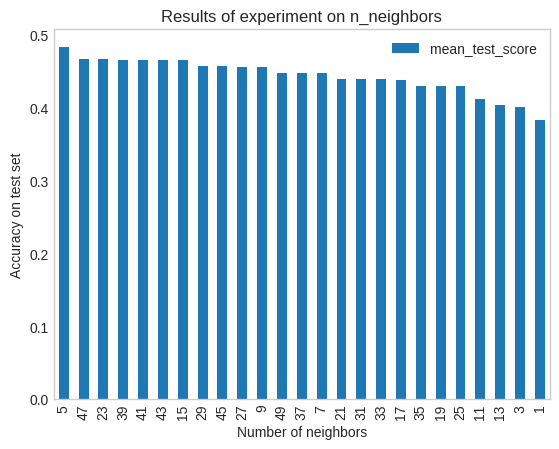

In [15]:
# KNN

knn_pipe = make_pipeline(imputer, ohe, MultiOutputClassifier(KNeighborsClassifier()))
knn_pipe.fit(X_train, y_train)

# Grid Searching
params = {'multioutputclassifier__estimator__n_neighbors': range(1, 50, 2)}
grid_for_pipeline = GridSearchCV(knn_pipe, param_grid=params)
grid_for_pipeline.fit(X_train, y_train)

# Plotting optimal number of neighbors
results = pd.DataFrame(grid_for_pipeline.cv_results_)[['param_multioutputclassifier__estimator__n_neighbors', 'mean_test_score']]
results = results.rename(columns={'param_multioutputclassifier__estimator__n_neighbors': 'param_n_neighbors'})

plt.style.use('seaborn-v0_8-whitegrid')
results.sort_values(by='mean_test_score', ascending=False).plot(kind='bar', x='param_n_neighbors', y='mean_test_score')
plt.grid()
plt.title('Results of experiment on n_neighbors')
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy on test set')

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


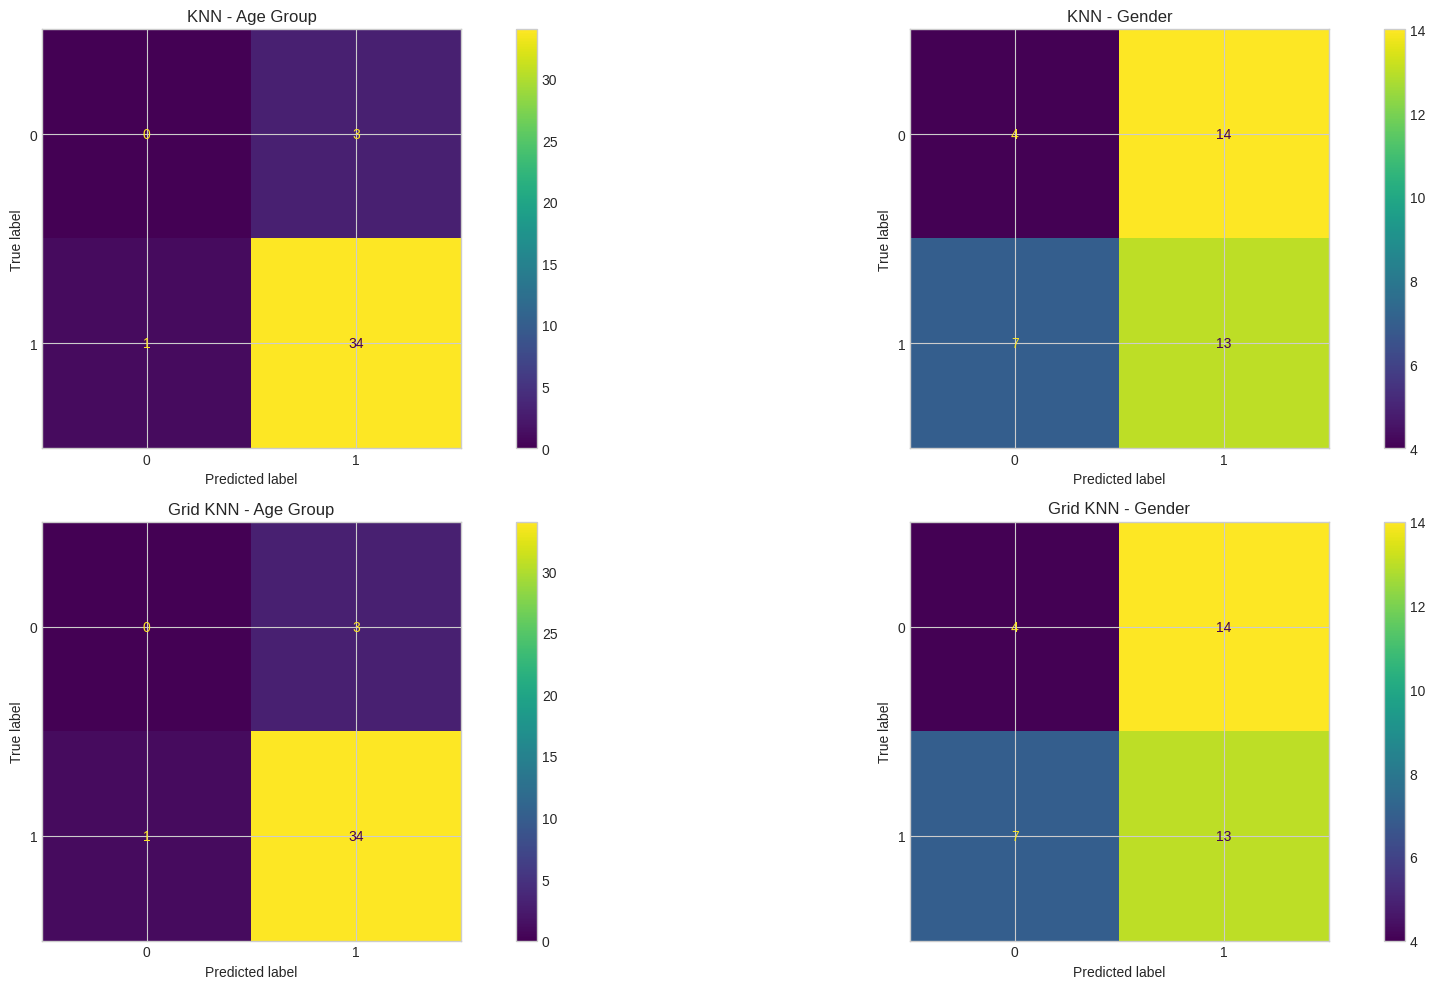

In [16]:
yhat_knn = knn_pipe.predict(X_test)
yhat_grid = grid_for_pipeline.predict(X_test)

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

# Age Group (column 0)
ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, 0], yhat_knn[:, 0], ax=axes[0, 0])
axes[0, 0].set_title('KNN - Age Group')

# Gender (column 1)
ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, 1], yhat_knn[:, 1], ax=axes[0, 1])
axes[0, 1].set_title('KNN - Gender')

# Grid - Age Group
ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, 0], yhat_grid[:, 0], ax=axes[1, 0])
axes[1, 0].set_title('Grid KNN - Age Group')

# Grid - Gender
ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, 1], yhat_grid[:, 1], ax=axes[1, 1])
axes[1, 1].set_title('Grid KNN - Gender')

plt.tight_layout()

In [17]:
print(knn_pipe.score(X_test, y_test))
print(grid_for_pipeline.best_score_)


0.3684210526315789
0.48300395256916995


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [18]:
print(f'Precision {precision_score(y_test, yhat_knn, average="weighted")}\nRecall: {recall_score(y_test, yhat_knn, average="weighted")}')

Precision 0.7598507598507599
Recall: 0.8545454545454545


### Model 3 Decision Tree (Grid Search tuned)

In [19]:
from sklearn.tree import DecisionTreeClassifier

tree_class = MultiOutputClassifier(DecisionTreeClassifier(random_state=42))
tree_pipe = make_pipeline(imputer, ohe, tree_class)
tree_pipe.fit(X_train, y_train)

y_pred = tree_pipe.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [20]:
print(X_train.columns.tolist())


['Profession', 'Daily_outfit', 'Color_palette', 'Functionality_vs_aesthetics', 'Wardrobe_type', 'Shopping_Frequency', 'Influence', 'Stores', 'Formal_event_attendance_frequency', 'Style_experimentation_frequency', 'Footwear', 'Activity Level', 'Importance of Clothing', 'Trendy vs Timeless', 'Clothing on Personality']


In [21]:
transformed = ohe.fit_transform(imputer.fit_transform(X_train))
print(transformed.select_dtypes('object').columns.tolist())


[]


## Confusion Matrix for Decision Tree before & after grid search

In [22]:
# Grid Search - Decision Tree hyperparameter tuning

# Parameter grid to search
param_grid = {
    'multioutputclassifier__estimator__max_depth': [3, 5, 7, 10, None],
    'multioutputclassifier__estimator__min_samples_split': [2, 5, 10],
    'multioutputclassifier__estimator__min_samples_leaf': [1, 2, 4],
    'multioutputclassifier__estimator__criterion': ['gini', 'entropy']
}

# Building the pipeline
dt_grid_pipe = make_pipeline(
    imputer, ohe, MultiOutputClassifier(DecisionTreeClassifier(random_state=42)))

grid_search = GridSearchCV(dt_grid_pipe, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u

Best params: {'multioutputclassifier__estimator__criterion': 'entropy', 'multioutputclassifier__estimator__max_depth': 7, 'multioutputclassifier__estimator__min_samples_leaf': 4, 'multioutputclassifier__estimator__min_samples_split': 10}
Best CV score: 0.4810276679841897


From above^

Best params: {'multioutputclassifier__estimator__criterion': 'entropy', 'multioutputclassifier__estimator__max_depth': 7, 'multioutputclassifier__estimator__min_samples_leaf': 4, 'multioutputclassifier__estimator__min_samples_split': 10}

Best CV score: 0.4810276679841897


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


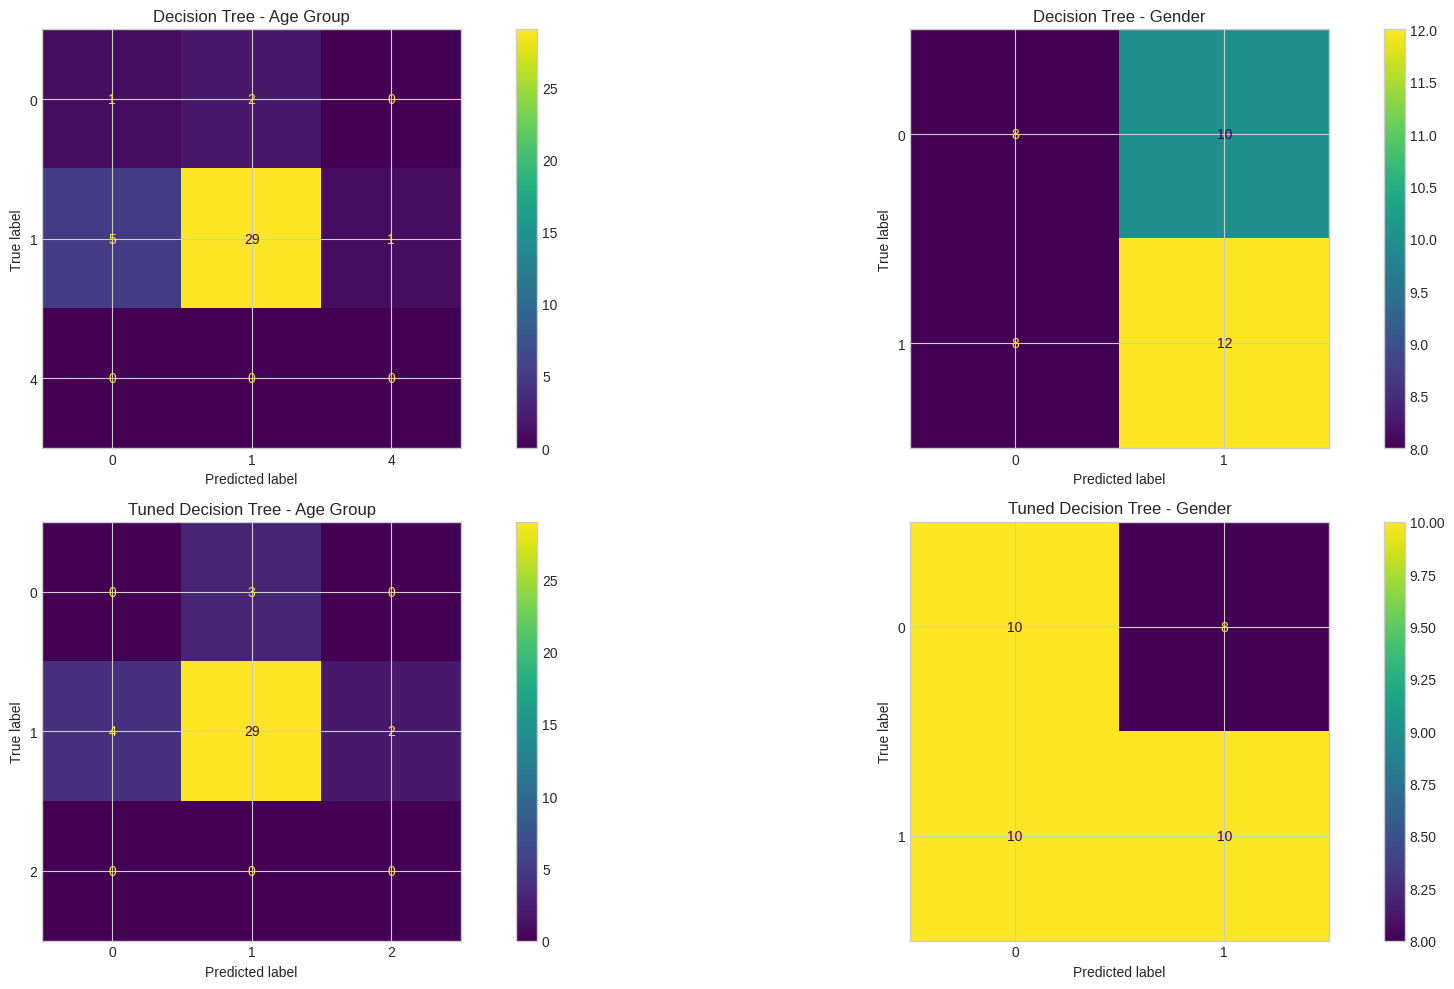

In [23]:
yhat_tree = tree_pipe.predict(X_test)
yhat_tree_grid = grid_search.best_estimator_.predict(X_test)

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, 0], yhat_tree[:, 0], ax=axes[0, 0])
axes[0, 0].set_title('Decision Tree - Age Group')

ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, 1], yhat_tree[:, 1], ax=axes[0, 1])
axes[0, 1].set_title('Decision Tree - Gender')

ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, 0], yhat_tree_grid[:, 0], ax=axes[1, 0])
axes[1, 0].set_title('Tuned Decision Tree - Age Group')

ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, 1], yhat_tree_grid[:, 1], ax=axes[1, 1])
axes[1, 1].set_title('Tuned Decision Tree - Gender')

plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder
print(y_test.iloc[:, 0].unique())
print(y_test.iloc[:, 1].unique())

[1 0]
[1 0]


In [25]:
print(y.iloc[:, 0].unique())


[1 2 0 4 3]


In [26]:
print(df['  1.Age Group  '].unique())

['18–24' '25–34' 'Under 18' '45+' '35–44']


In [27]:
y = df[['  1.Age Group  ', '  2.Gender  ']]
print(y.iloc[:, 0].unique())

['18–24' '25–34' 'Under 18' '45+' '35–44']


In [28]:
print(df.columns.tolist())

['  1.Age Group  ', '  2.Gender  ', 'Profession', 'Daily_outfit', 'Color_palette', 'Functionality_vs_aesthetics', 'Wardrobe_type', 'Shopping_Frequency', 'Influence', 'Stores', 'Formal_event_attendance_frequency', 'Style_experimentation_frequency', 'Footwear', 'Activity Level', 'Importance of Clothing', 'Trendy vs Timeless', 'Clothing on Personality']



# Evaluation of confusion matrix


| Model | Age Group Acc. | Gender Acc. |
|---|---|---|
| Before(original) | Most effective for the 18-24 age group, however unable to capture 45+ age group and only 1 correct for under 18 |Correctly predicted female but not male and vice versa (essentially based on estimations rather than concrete patterns) |
| After (tuned) | More correct for 18-24, however, the model considers everything to be correlated to this group, resulted in a 0 for 25-34 & under 18|Tuning made no meaningful difference for gender, reducing accurate identifications for female |

Overall, one can infer that while the model improved for age groups, the model tended to overfit the 18-24 age group, sacrificing the minority groups in the process. Additionally, gender is essentially unpredictable from this dataset.



In [29]:
# param_grid and dt_grid_pipe are defined above in the grid search cell

In [30]:
# evaluation before grid search
y_pred = tree_pipe.predict(X_test)
print("Age Decision Tree Accuracy:", accuracy_score(y_test['  1.Age Group  '], y_pred[:, 0]))
print("Gender Decision Tree Accuracy:", accuracy_score(y_test['  2.Gender  '], y_pred[:, 1]))

Age Decision Tree Accuracy: 0.7894736842105263
Gender Decision Tree Accuracy: 0.5263157894736842


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


# Before grid search:

**Age Decision Tree Accuracy**: 0.7894736842105263

**Gender Decision Tree Accuracy**: 0.5263157894736842

In [31]:
#evaluation after grid search
y_pred_best = grid_search.best_estimator_.predict(X_test)
print("Age Decision Tree Accuracy tuned model", accuracy_score(y_test.iloc[:, 0], y_pred_best[:, 0]))
print("Gender Decision Tree Accuracy tuned model:", accuracy_score(y_test.iloc[:, 1], y_pred_best[:, 1]))

Age Decision Tree Accuracy tuned model 0.7631578947368421
Gender Decision Tree Accuracy tuned model: 0.5263157894736842


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Tuned Model:

**Age Decision Tree Accuracy tuned model**: 0.7631578947368421

**Gender Decision Tree Accuracy tuned model**: 0.5263157894736842

# Classification reports for Decision Tree Classifier Model:

## Evaluation of model before grid search:

In [32]:
#evaluation of model before grid search
print("Age Group")
print(classification_report(y_test.iloc[:, 0], y_pred[:, 0]))

print("Gender")
print(classification_report(y_test.iloc[:, 1], y_pred[:, 1]))

Age Group
              precision    recall  f1-score   support

           0       0.17      0.33      0.22         3
           1       0.94      0.83      0.88        35
           4       0.00      0.00      0.00         0

    accuracy                           0.79        38
   macro avg       0.37      0.39      0.37        38
weighted avg       0.87      0.79      0.83        38

Gender
              precision    recall  f1-score   support

           0       0.50      0.44      0.47        18
           1       0.55      0.60      0.57        20

    accuracy                           0.53        38
   macro avg       0.52      0.52      0.52        38
weighted avg       0.52      0.53      0.52        38



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Evaluation of model after grid search:

In [33]:
#evaluation of model after grid search
print("Age Group")
print(classification_report(y_test.iloc[:, 0], y_pred_best[:, 0]))

print("Gender")
print(classification_report(y_test.iloc[:, 1], y_pred_best[:, 1]))

Age Group
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.91      0.83      0.87        35
           2       0.00      0.00      0.00         0

    accuracy                           0.76        38
   macro avg       0.30      0.28      0.29        38
weighted avg       0.83      0.76      0.80        38

Gender
              precision    recall  f1-score   support

           0       0.50      0.56      0.53        18
           1       0.56      0.50      0.53        20

    accuracy                           0.53        38
   macro avg       0.53      0.53      0.53        38
weighted avg       0.53      0.53      0.53        38



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


---
## Conclusion

### Model Comparison

| Model | Age Group Acc. | Gender Acc. |
|---|---|---|
| Logistic Regression (baseline) | ~87 % | ~63 % |
| KNN (tuned) | ~37 % (combined score) | ~53 % |
| Decision Tree (baseline) | ~79 % | ~53 % |
| Decision Tree (tuned) | ~76 % | ~53 % |

- **Logistic Regression** achieves the highest Age Group accuracy (~87%), outperforming the tuned Decision Tree, suggesting a linear boundary is sufficient given the dataset size.
- **Gender** prediction is unreliable (~53–63%) across all models, suggesting that fashion preferences in this survey are not strongly gender-specific and the dataset is too small to learn meaningful patterns.

---
## Analysis: Which Model Performs Best?

Based on the results above, **Logistic Regression (baseline)** is the strongest overall model, achieving the highest **Age Group accuracy (~87%)** — outperforming both the baseline Decision Tree (about 79%) and the tuned Decision Tree (about 76%). This is a notable finding: tuning the Decision Tree via Grid Search actually slightly *reduced* its Age Group accuracy, likely because cross-validation on the small dataset (~150 rows) led the tuner to select overly conservative hyperparameters that sacrifice test-set performance.

For **Gender prediction**, no model performs meaningfully above chance — Logistic Regression reaches ~63%, while the Decision Tree and KNN hover around 53%. This strongly suggests that fashion preferences in this survey are not sufficiently gender-differentiated for any classifier to exploit reliably at this sample size.

KNN performs the worst overall (~37% combined test score), likely due to the curse of dimensionality from the high-dimensional one-hot encoded feature space.

**Verdict:** **Logistic Regression** wins on Age Group prediction. No model meaningfully predicts Gender — the dataset is too small and the gender signal too weak for any classifier to exploit reliably.


## Next Steps


**1. Collect More Responses**
The dataset only has ~150 rows, which is quite small. Getting more survey responses would help all the models learn better patterns and reduce the chance of overfitting to a particular group.

**2. Try More Models**
We only tested three classifiers. It would be easy to try a Random Forest (which is just many Decision Trees working together) and see if it does better — it is a small code change and often improves accuracy.

**3. Balance the Age Groups**
The 18-24 age group makes up most of the data, so the models just predict that group most of the time. A simple fix is to use class_weight=balanced in the Logistic Regression, which tells the model to pay more attention to the smaller groups.

**4. Train Separate Models per Target**
Right now we predict Age Group and Gender at the same time using Multi-OutputClassifier. It might work better to train one model just for Age Group and a separate one just for Gender, so each can be tuned independently.